# Customer Segmentation Using RFM Analysis
###By Shaimaa M. Abdel-Aal

In this project , we analyze customer purchasing behavior using RFM (Recency, Frequency, Monetary) analysis.
the goal is to segment customers into different groups based on:
- How recently they purchased?
- How often they purchase?
- How much money they spend ?

This segmentation helps businesses design targeted marketing strategies for different customer groups.

##Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
%matplotlib inline
sns.set(style="whitegrid")

###Previewing the Dataset
here we display the first few rows of the dataset to understand its structure and columns

In [ ]:
df = pd.read_excel("Online Retail.xlsx")
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


##Data Cleaning
Cleaning steps include:
- Removing rows with missing CustomerID
- Remoning Cancelled transactions
- Removing negative or zero quantities
- Creating new column (TotalPrice = Quantity * unit price ) to know how much each transaction contributed:


In [ ]:
#Removing rows with missing CustomerID
df=df.dropna(subset=['CustomerID'])
#Remove cancelled transactions
df=df[~df['InvoiceNo'].astype(str).str.startswith('C')]
#Removing Negative or Zero Quantities
df=df[df['Quantity']>0]
#Creating new column TotalPrice
df['TotalPrice']= df['Quantity'] * df['UnitPrice']
#Ensuring correct data format
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])


In [ ]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 397924 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397924 non-null  object        
 1   StockCode    397924 non-null  object        
 2   Description  397924 non-null  object        
 3   Quantity     397924 non-null  int64         
 4   InvoiceDate  397924 non-null  datetime64[ns]
 5   UnitPrice    397924 non-null  float64       
 6   CustomerID   397924 non-null  float64       
 7   Country      397924 non-null  object        
 8   TotalPrice   397924 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.4+ MB


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


##Calculating Recency


In [ ]:
today_date= df['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Refrence date for Recency: ",today_date)

recency_df=df.groupby('CustomerID')['InvoiceDate'].max().reset_index()
recency_df['Recency']=(today_date-recency_df['InvoiceDate']).dt.days
recency_df.head()


Refrence date for Recency:  2011-12-10 12:50:00


,CustomerID,InvoiceDate,Recency
0,12346.0,2011-01-18 10:01:00,326
1,12347.0,2011-12-07 15:52:00,2
2,12348.0,2011-09-25 13:13:00,75
3,12349.0,2011-11-21 09:51:00,19
4,12350.0,2011-02-02 16:01:00,310


##Calculating Frequency

In [ ]:
frequency_df = df.groupby('CustomerID')['InvoiceNo'].count().reset_index()
frequency_df.rename(columns={'InvoiceNo':'Frequency'}, inplace=True)
frequency_df.head()

,CustomerID,Frequency
0,12346.0,1
1,12347.0,182
2,12348.0,31
3,12349.0,73
4,12350.0,17


##Calculating Monetary

In [ ]:
monetary_df = df.groupby('CustomerID')['TotalPrice'].sum().reset_index()
monetary_df.rename(columns={'TotalPrice':'Monetary'}, inplace=True)
monetary_df.head()

,CustomerID,Monetary
0,12346.0,77183.60
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40


In [ ]:
df[df['CustomerID']== 12346.0 ]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,77183.6


##Creating the RFM Table


In [ ]:
rfm=recency_df.merge(frequency_df,on='CustomerID')
rfm=rfm.merge(monetary_df,on='CustomerID')
rfm.head()

,CustomerID,InvoiceDate,Recency,Frequency,Monetary
0,12346.0,2011-01-18 10:01:00,326,1,77183.60
1,12347.0,2011-12-07 15:52:00,2,182,4310.00
2,12348.0,2011-09-25 13:13:00,75,31,1797.24
3,12349.0,2011-11-21 09:51:00,19,73,1757.55
4,12350.0,2011-02-02 16:01:00,310,17,334.40


## RFM Scores
converting RFM values into scores from 1 to 5
- Recency: lower is better
- Freqency: higher is better
- Monetary: higher is better

In [ ]:
rfm['R_Score']=pd.qcut(rfm['Recency'],5,labels=[5,4,3,2,1])
rfm['F_Score']=pd.qcut(rfm['Frequency'].rank(method='first'),5,labels=[1,2,3,4,5])
rfm['M_Score']=pd.qcut(rfm['Monetary'],5,labels=[1,2,3,4,5])
rfm.head()

,CustomerID,InvoiceDate,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,12346.0,2011-01-18 10:01:00,326,1,77183.60,1,1,5
1,12347.0,2011-12-07 15:52:00,2,182,4310.00,5,5,5
2,12348.0,2011-09-25 13:13:00,75,31,1797.24,2,3,4
3,12349.0,2011-11-21 09:51:00,19,73,1757.55,4,4,4
4,12350.0,2011-02-02 16:01:00,310,17,334.40,1,2,2


##Customer Segmentation
- Champions customers
- Loyal customers
- At risk customers
- Lost customers

In [ ]:
def segment_customer(row):
  if row['R_Score'] >=4 and row['F_Score'] >=4 and row['M_Score'] >=4 :
    return 'Champions'
  elif row['F_Score']>=4 and row['M_Score'] >=3:
    return 'Loyal Customers'
  elif row['M_Score'] >=4:
    return 'Big Spenders'
  elif row['R_Score'] >=4:
    return 'New Customers'
  elif row['R_Score'] <= 1 and row['F_Score'] <= 1:
    return 'Lost Customers'
  elif row['R_Score'] <=2:
    return 'At Risk'
  else:
    return 'Regular Customers'
rfm['Segment']=rfm.apply(segment_customer,axis=1)
rfm.head()


,CustomerID,InvoiceDate,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,Segment
0,12346.0,2011-01-18 10:01:00,326,1,77183.60,1,1,5,Big Spenders
1,12347.0,2011-12-07 15:52:00,2,182,4310.00,5,5,5,Champions
2,12348.0,2011-09-25 13:13:00,75,31,1797.24,2,3,4,Big Spenders
3,12349.0,2011-11-21 09:51:00,19,73,1757.55,4,4,4,Champions
4,12350.0,2011-02-02 16:01:00,310,17,334.40,1,2,2,At Risk


## Business Insights and Marketing Recommendations

In this section, we analyze customer segments and provide marketing strategies for each group.

The goal is to help businesses improve customer retention and increase revenue.



In [ ]:
rfm['Segment'].value_counts()

,count
Segment,
At Risk,975
Champions,932
Loyal Customers,667
New Customers,575
Regular Customers,479
Big Spenders,368
Lost Customers,343


###Business Insights
The customer segmentation results show that a significant number of customers fall into At Risk category which indicates potential opportunities for re-engagement marketing campaigns.
The presence of a large number of Champions customers indicates strong customer loyalty and revenue stability

###Suggest simple marketing ideas for each group

- Champions Customers: Offer VIP loyality programs
- Loyal Customers: Offer discountes and reward points
- Big Spenders: Offer premium products
- At Risk Customers: Send re-engagement campaigns
- Lost Customers: Offer strong discount campaigns

#Visualization

##Recency Distribution

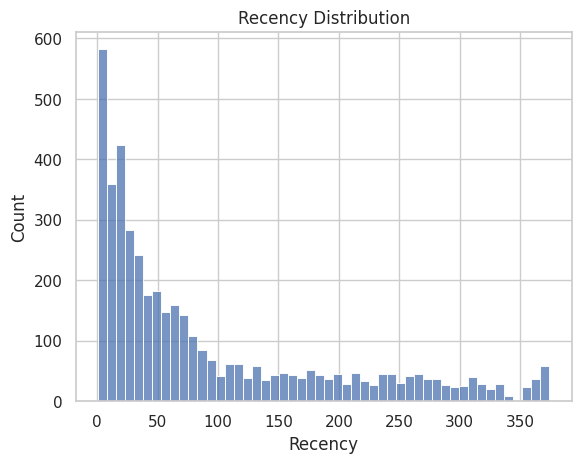

In [ ]:
sns.histplot(rfm['Recency'],bins=50)
plt.title('Recency Distribution')
plt.show()


###Frequency Distribution

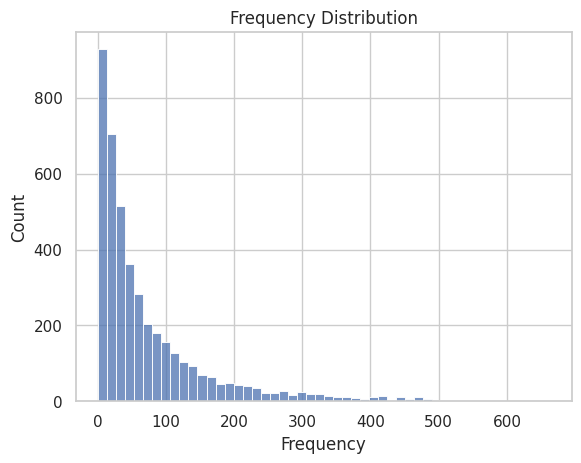

In [ ]:
rfm_filtered = rfm[rfm['Frequency'] < rfm['Frequency'].quantile(0.99)]
sns.histplot(rfm_filtered['Frequency'],bins=50)
plt.title('Frequency Distribution')
plt.show()

###Monetary Distribution

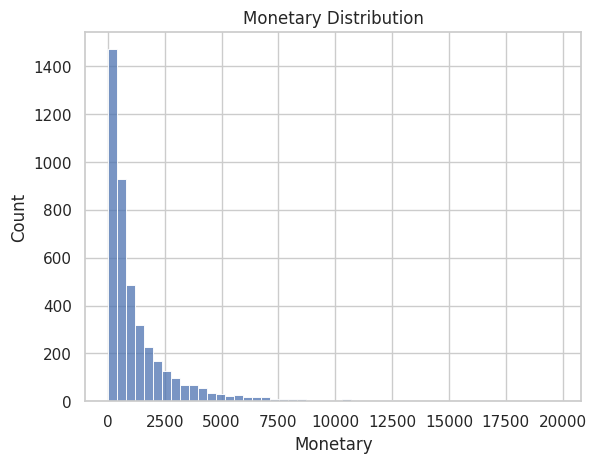

In [ ]:
rfm_filtered = rfm[rfm['Monetary'] < rfm['Monetary'].quantile(0.99)]
sns.histplot(rfm_filtered['Monetary'],bins=50)
plt.title('Monetary Distribution')
plt.show()

###Customer Segment Percent
(Pie Chart)



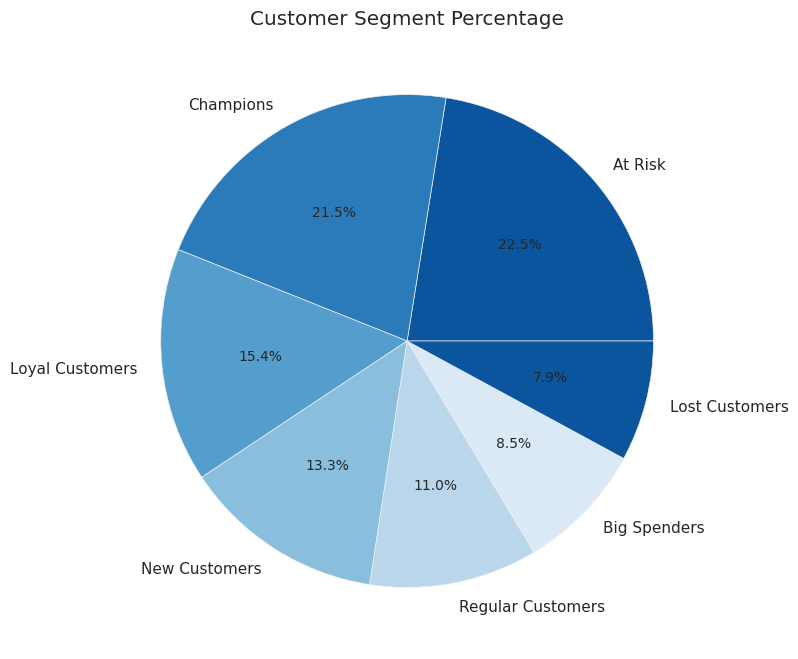

In [ ]:
plt.figure(figsize=(8,8))
colors=sns.color_palette("Blues_r")
rfm['Segment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=colors,
    figsize=(8,8)
)

plt.title('Customer Segment Percentage')
plt.ylabel('')
plt.show()

###Heatmap
Relation of RFM metrics

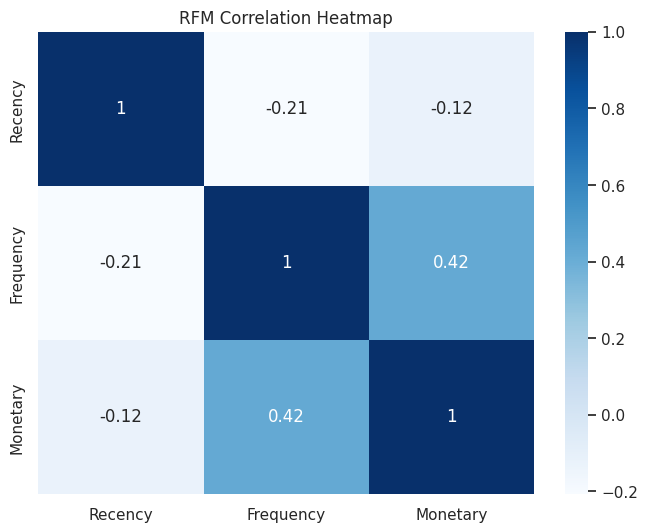

In [ ]:

plt.figure(figsize=(8,6))

sns.heatmap(
    rfm[['Recency','Frequency','Monetary']].corr(),
    annot=True,
    cmap='Blues'
)

plt.title('RFM Correlation Heatmap')
plt.show()